# Задание 1. Аналитика добычи

In [1]:
import sys, os
sys.path.insert(0, '/home/jovyan/work/etl')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from io_utils import read_table, write_mart, write_mart_to_pg, pg_engine

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')


## Загрузка

In [2]:
wells       = read_table('wells')
production  = read_table('production')
telemetry   = read_table('telemetry')

print('wells     :', wells.shape)
print('production:', production.shape)
print('telemetry :', telemetry.shape)
wells.head()


wells     : (10, 8)
production: (810, 7)
telemetry : (19440, 7)


,well_id,well_name,field_name,region,well_type,drill_date,depth_m,is_active
0,1,W-001,Самотлорское,ХМАО,oil,2015-03-12,2850.50,True
1,2,W-002,Самотлорское,ХМАО,oil,2016-07-08,3100.00,True
2,3,W-003,Приобское,ХМАО,oil,2014-11-20,2780.00,True
3,4,W-004,Приобское,ХМАО,mixed,2017-02-14,2950.75,True
4,5,W-005,Ванкорское,Красноярский край,oil,2018-05-22,3200.00,True


## NULL %

In [3]:
def null_pct(df):
    return (df.isna().mean() * 100).round(2).sort_values(ascending=False)

print('production:'); print(null_pct(production)); print()
print('telemetry :'); print(null_pct(telemetry))


production:
oil_tons          1.85
water_tons        1.23
production_id     0.00
well_id           0.00
prod_date         0.00
gas_m3            0.00
downtime_hours    0.00
dtype: float64

telemetry :
pressure_bar     0.26
telemetry_id     0.00
well_id          0.00
ts               0.00
temperature_c    0.00
power_kw         0.00
pump_hours       0.00
dtype: float64


## Очистка

In [4]:
prod = production.copy()
prod['oil_tons']   = prod.groupby('well_id')['oil_tons'].transform(lambda s: s.fillna(s.median()))
prod['water_tons'] = prod.groupby('well_id')['water_tons'].transform(lambda s: s.fillna(s.median()))

tel = telemetry.copy()
tel['pressure_bar'] = tel.groupby('well_id')['pressure_bar'].transform(lambda s: s.fillna(s.median()))

q1, q3 = tel['pressure_bar'].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
before = len(tel)
tel = tel[(tel['pressure_bar'] >= lo) & (tel['pressure_bar'] <= hi)]
print(f'Удалено выбросов: {before - len(tel)} строк ({(before-len(tel))/before:.1%})')


Удалено выбросов: 30 строк (0.2%)


## Добыча по дням

In [5]:
daily_production = (
    prod.groupby('prod_date', as_index=False)
        .agg(total_oil_tons=('oil_tons', 'sum'),
             total_gas_m3=('gas_m3', 'sum'),
             total_water_tons=('water_tons', 'sum'),
             active_wells=('well_id', 'nunique'))
        .sort_values('prod_date')
)
daily_production['prod_date'] = pd.to_datetime(daily_production['prod_date'])
daily_production.head()


,prod_date,total_oil_tons,total_gas_m3,total_water_tons,active_wells
0,2025-01-01,507.97,126454.56,143.77,9
1,2025-01-02,560.05,116767.33,112.05,9
2,2025-01-03,459.82,118815.74,176.90,9
3,2025-01-04,553.00,121034.17,149.58,9
4,2025-01-05,516.34,89565.54,153.57,9


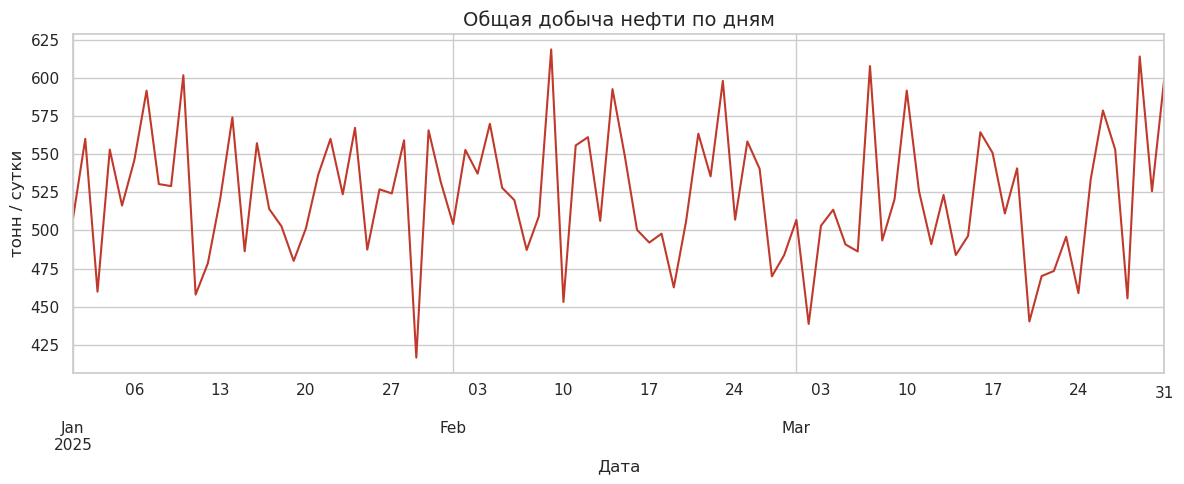

In [6]:
ax = daily_production.plot(x='prod_date', y='total_oil_tons', legend=False, color='#c0392b')
ax.set_title('Общая добыча нефти по дням', fontsize=14)
ax.set_ylabel('тонн / сутки'); ax.set_xlabel('Дата')
plt.tight_layout(); plt.show()


## KPI по скважинам

In [7]:
kpi = (
    prod.groupby('well_id', as_index=False)
        .agg(avg_oil_tons=('oil_tons', 'mean'),
             total_oil_tons=('oil_tons', 'sum'),
             avg_downtime=('downtime_hours', 'mean'),
             days=('prod_date', 'count'))
)
kpi['downtime_pct'] = (kpi['avg_downtime'] / 24 * 100).round(2)
kpi['avg_oil_tons'] = kpi['avg_oil_tons'].round(2)
kpi = kpi.merge(wells[['well_id', 'well_name', 'field_name', 'well_type']], on='well_id')

best  = kpi.nlargest(3, 'avg_oil_tons')[['well_name', 'field_name', 'avg_oil_tons', 'downtime_pct']]
worst = kpi.nsmallest(3, 'avg_oil_tons')[['well_name', 'field_name', 'avg_oil_tons', 'downtime_pct']]
print('TOP-3:'); print(best.to_string(index=False))
print('\nBOTTOM-3:'); print(worst.to_string(index=False))
kpi


TOP-3:
well_name   field_name  avg_oil_tons  downtime_pct
    W-009 Ромашкинское        103.22          1.87
    W-005   Ванкорское         87.40          2.44
    W-004    Приобское         79.99          1.28

BOTTOM-3:
well_name  field_name  avg_oil_tons  downtime_pct
    W-007 Уренгойское         11.61          1.30
    W-008 Уренгойское         12.14          1.26
    W-006  Ванкорское         12.34          1.56


,well_id,avg_oil_tons,total_oil_tons,avg_downtime,days,downtime_pct,well_name,field_name,well_type
0,1,68.00,6119.63,0.224444,90,0.94,W-001,Самотлорское,oil
1,2,72.79,6551.08,0.450778,90,1.88,W-002,Самотлорское,oil
2,3,75.47,6792.40,0.239111,90,1.00,W-003,Приобское,oil
3,4,79.99,7199.49,0.306889,90,1.28,W-004,Приобское,mixed
4,5,87.40,7866.34,0.585222,90,2.44,W-005,Ванкорское,oil
5,6,12.34,1110.47,0.373889,90,1.56,W-006,Ванкорское,gas
6,7,11.61,1044.58,0.312222,90,1.30,W-007,Уренгойское,gas
7,8,12.14,1092.89,0.303333,90,1.26,W-008,Уренгойское,gas
8,9,103.22,9289.48,0.449889,90,1.87,W-009,Ромашкинское,oil


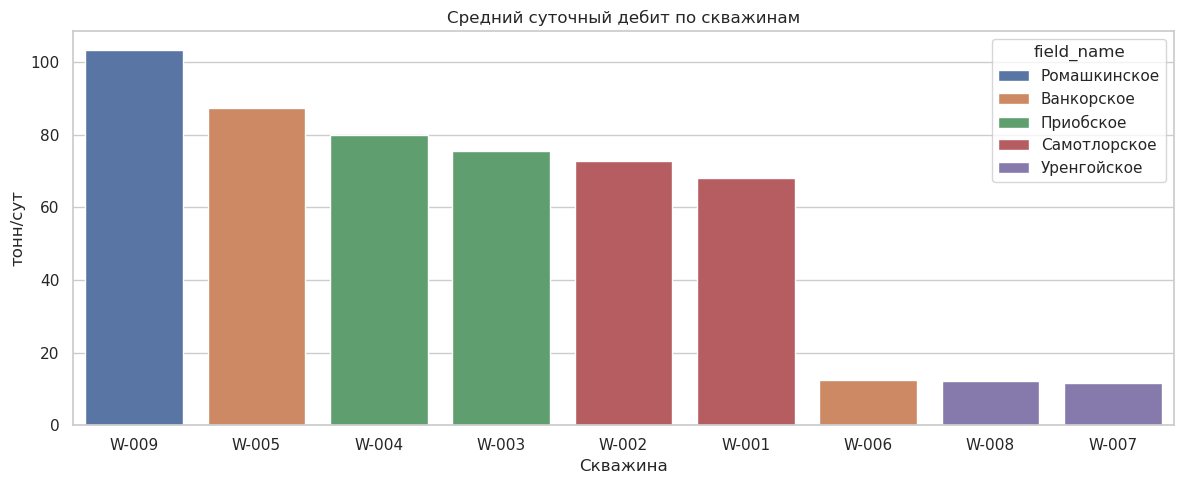

In [8]:
plot_df = kpi.sort_values('avg_oil_tons', ascending=False)
ax = sns.barplot(data=plot_df, x='well_name', y='avg_oil_tons',
                 hue='field_name', dodge=False)
ax.set_title('Средний суточный дебит по скважинам')
ax.set_ylabel('тонн/сут'); ax.set_xlabel('Скважина')
plt.tight_layout(); plt.show()


## Влияние давления и температуры

In [9]:
tel['date'] = pd.to_datetime(tel['ts']).dt.date
tel_daily = (
    tel.groupby(['well_id', 'date'], as_index=False)
       .agg(avg_pressure=('pressure_bar', 'mean'),
            avg_temperature=('temperature_c', 'mean'),
            avg_power=('power_kw', 'mean'),
            sum_pump_hours=('pump_hours', 'sum'))
)
tel_daily['date'] = pd.to_datetime(tel_daily['date'])
prod['prod_date'] = pd.to_datetime(prod['prod_date'])

mart_production = (
    prod.merge(tel_daily, left_on=['well_id', 'prod_date'], right_on=['well_id', 'date'])
        .merge(wells[['well_id', 'well_name', 'field_name', 'region', 'well_type']], on='well_id')
        .drop(columns=['date'])
)
mart_production['downtime_pct'] = (mart_production['downtime_hours'] / 24 * 100).round(2)
mart_production.head()


,production_id,well_id,prod_date,oil_tons,gas_m3,water_tons,downtime_hours,avg_pressure,avg_temperature,avg_power,sum_pump_hours,well_name,field_name,region,well_type,downtime_pct
0,1,1,2025-01-01,79.58,2812.35,23.73,0.0,171.547083,71.530000,506.838333,17.03,W-001,Самотлорское,ХМАО,oil,0.0
1,10,1,2025-01-02,84.56,1093.95,9.69,0.0,172.996667,72.038333,494.916250,17.89,W-001,Самотлорское,ХМАО,oil,0.0
2,19,1,2025-01-03,54.36,4273.54,22.01,0.0,173.785000,74.367917,498.984583,18.21,W-001,Самотлорское,ХМАО,oil,0.0
3,28,1,2025-01-04,92.42,3896.09,18.12,0.0,174.071667,72.592500,503.523333,18.03,W-001,Самотлорское,ХМАО,oil,0.0
4,37,1,2025-01-05,81.35,5622.84,9.82,0.0,175.242083,73.060417,505.595833,16.91,W-001,Самотлорское,ХМАО,oil,0.0


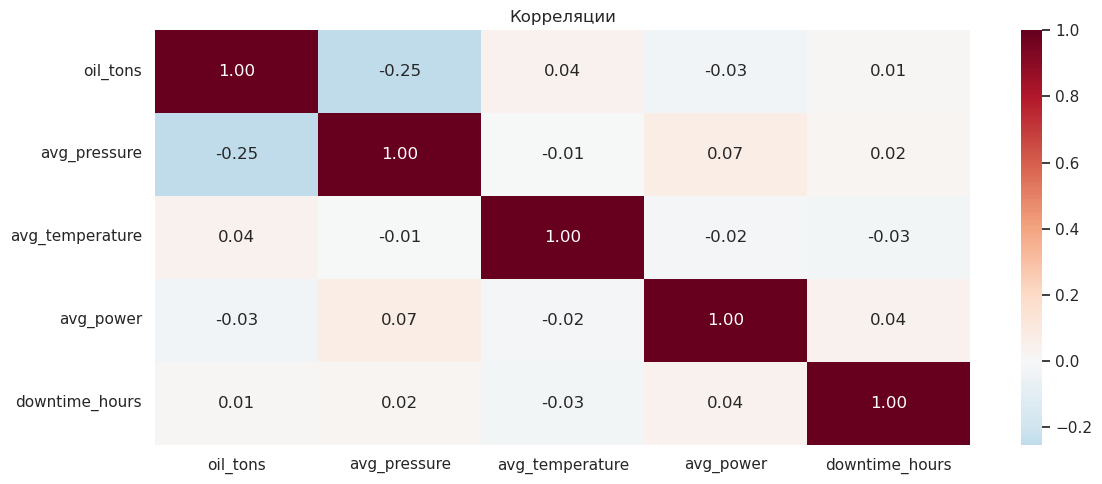

In [10]:
corr = mart_production[['oil_tons', 'avg_pressure', 'avg_temperature', 'avg_power', 'downtime_hours']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Корреляции'); plt.tight_layout(); plt.show()


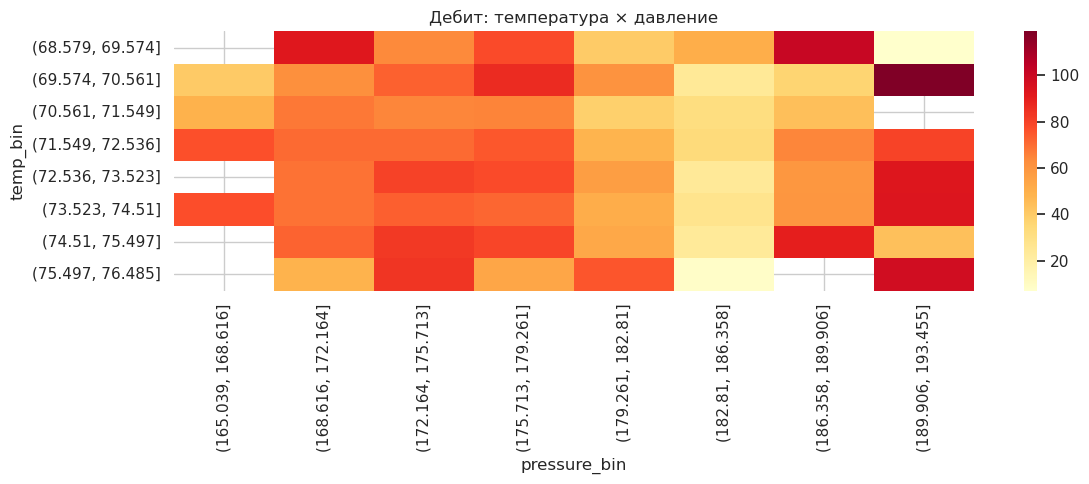

In [11]:
plot_df = mart_production.copy()
plot_df['pressure_bin'] = pd.cut(plot_df['avg_pressure'], bins=8)
plot_df['temp_bin']     = pd.cut(plot_df['avg_temperature'], bins=8)
pivot = plot_df.pivot_table(index='temp_bin', columns='pressure_bin',
                            values='oil_tons', aggfunc='mean', observed=True)
sns.heatmap(pivot, cmap='YlOrRd', annot=False)
plt.title('Дебит: температура × давление'); plt.tight_layout(); plt.show()


## Сохранение витрины

In [12]:
uri = write_mart(mart_production, 'mart_production')
write_mart_to_pg(mart_production, 'mart_production')
print('Saved:', uri)


Saved: s3://marts/mart_production.parquet
